# Notebook 0 — Build labelled building footprints

The published PWTT benchmark gives us **one** assessment date per city. UNOSAT
actually published **nine** for Gaza. This notebook rebuilds the label files
ourselves so we can use all of them, following PWTT's own labelling rules so
the results stay comparable.

**The five steps**

1. Read every UNOSAT geodatabase and pool them into one damage dataset.
2. Download Microsoft Building Footprints for the Gaza Strip.
3. Clean the footprints the way PWTT does.
4. Join points to buildings the way PWTT does, once per assessment date.
5. Check the result against the published benchmark file.

**Why more dates matter.** With one date, the temporal label augmentation in
notebook 2 does nothing. With nine, a building's label becomes a sequence, so
the model can learn from damage that happened at different times instead of
seeing only the final state.

**Test cities.** Raqqa, Mosul, Chernihiv and Rubizhne are registered here as
holdout cities (`role: "holdout"` in `CITIES`) — this notebook builds their
label CSVs the same way it builds Gaza's, but nothing here trains on them or
uses them for model selection. That gate belongs to the split configuration
in `pipeline.py` / notebook 2, which is not updated yet; for now, treating
these cities as held out is a matter of discipline (don't add them to a
training or validation split) until that catches up. (Mariupol was the
original fourth choice but had no usable post-invasion point data in the
available release — see the note after the `CITIES` cell.)

Run this once, before notebook 1.

## 1. Setup

Keep each `.gdb` as a **whole folder** — it looks like a file but is a
directory of ~20 machine-named files that only work together.

```
War-Damage-Detection/
    Data/UNOSAT/
        UNOSAT_GazaStrip_CDA_07Jan2024.gdb/     <- Gaza releases,
        UNOSAT_GazaStrip_CDA_06September2024.gdb/   one per assessment
        ...
        CE20130604SYR_Raqqa_Deir.gdb/           <- one release per test city
        CE20140613IRQ_Mosul_damage_assessment.gdb/
        Damage_assessment_Mosul_20170804.gdb/
        CE20220223UKR_UNOSAT_Chernihiv_Damage.gdb/
        UNOSAT_CE20220223UKR_Rubizhne_CDA_20220709.gdb/
    one_month/            <- the published PWTT benchmark (for checking)
    own_footprints/       <- written by this notebook
    footprints_cache/     <- written by this notebook
```

`UNOSAT_DIR` now holds releases for Gaza plus the four held-out test cities
(Raqqa, Mosul, Chernihiv, Rubizhne) side by side. `ONLY_GDBS`, right below,
restricts a given run to a subset of filenames — use it so that adding or
debugging one city does not re-scan and re-download everything else.

In [32]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q mercantile pyogrio

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
import os
import re
import glob
import json
from datetime import datetime

import numpy as np
import pandas as pd
import geopandas as gpd
import mercantile
import pyogrio
from shapely import geometry
from shapely.ops import transform
from tqdm.auto import tqdm

BASE = "/content/drive/MyDrive/War-Damage-Detection"   # adjust if needed
UNOSAT_DIR = os.path.join(BASE, "Data", "UNOSAT")
PWTT_DIR = os.path.join(BASE, "Data", "one_month")          # published benchmark
OUT_DIR = os.path.join(BASE, "Data", "own_footprints")      # our labelled CSVs
FOOTPRINT_CACHE = os.path.join(BASE, "Data", "footprints_cache")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FOOTPRINT_CACHE, exist_ok=True)

# Microsoft's index of building-footprint tiles (one row per quadkey)
MS_LINKS_URL = ("https://minedbuildings.z5.web.core.windows.net/"
                "global-buildings/dataset-links.csv")

# UNOSAT_DIR now holds .gdb releases for several cities at once, and some of
# them are large multi-city regional exports (see Section 2). Re-scanning
# every file on every run gets slow and, worse, re-reads Gaza's releases even
# when you are only iterating on a newly added city. ONLY_GDBS restricts this
# run to a subset of filenames; leave it None to scan everything.
#
#   ONLY_GDBS = ["CE20130604SYR_Raqqa_Deir.gdb"]   # just Raqqa, this run
#
ONLY_GDBS = ["UNOSAT_CE20220223UKR_Rubizhne_CDA_20220709.gdb"] #None

gdb_paths = sorted(glob.glob(os.path.join(UNOSAT_DIR, "*.gdb")))
if ONLY_GDBS is not None:
    keep = set(ONLY_GDBS)
    missing = keep - {os.path.basename(p) for p in gdb_paths}
    if missing:
        print(f"ONLY_GDBS names not found in {UNOSAT_DIR}: {sorted(missing)}")
    gdb_paths = [p for p in gdb_paths if os.path.basename(p) in keep]

print(f"{len(gdb_paths)} geodatabases selected"
      f"{' (ONLY_GDBS active)' if ONLY_GDBS is not None else ''} in {UNOSAT_DIR}:")
for p in gdb_paths:
    print("  ", os.path.basename(p))
if not gdb_paths:
    print("\nNothing found. Check UNOSAT_DIR and ONLY_GDBS, and that each .gdb "
          "is an unzipped FOLDER rather than a zip that happens to end in .gdb.")

1 geodatabases selected (ONLY_GDBS active) in /content/drive/MyDrive/War-Damage-Detection/Data/UNOSAT:
   UNOSAT_CE20220223UKR_Rubizhne_CDA_20220709.gdb


## 2. The PWTT rules

Everything that has to match the published benchmark is in this one cell. All
three values are copied from `run_eval` in the PWTT repository's
`code/eval.py`, so you can check them against the source rather than taking
them on trust.

| our setting | PWTT source line | what it does |
|---|---|---|
| `GAZA_AOI` | `gaza = ee.Geometry.Polygon([...])` | the area to include |
| `MIN_AREA_M2 = 50` | `.filter(ee.Filter.gt('area', 50))` | drops tiny geometries |
| `SNAP_M = 10` | `points.map(lambda f: f.buffer(10))` | tolerance for the join |

**The outline, not a box.** The Gaza Strip is a narrow band running
south-west to north-east. A rectangle around it also contains a wedge of
Israeli territory, whose buildings are real, undamaged, and never assessed by
UNOSAT — so they enter the denominator and deflate the damaged share.
PWTT hand-drew a 20-vertex outline instead, which we copy exactly.

**The area filter.** Microsoft's footprints are model-derived, and the layer
contains artifacts: sheds, vehicles, wall fragments, shadows. At Sentinel-1's
10 m resolution a 20 m² object is a fifth of one pixel, so there is nothing
there to learn from. PWTT drops everything at or below 50 m².

**The snap tolerance.** UNOSAT points do not land perfectly inside their
building — polygon edges and annotation both carry error, and a strict
"point inside polygon" test misses about a fifth of them. PWTT buffers every
point by 10 m and keeps any building the circle touches.

In [35]:
# --- copied from run_eval() in the PWTT repo, code/eval.py -------------------

GAZA_AOI = geometry.Polygon([
    [34.216324, 31.325772], [34.235206, 31.296147], [34.244819, 31.276782],
    [34.252373, 31.253305], [34.263702, 31.231290], [34.282928, 31.233932],
    [34.340263, 31.266805], [34.378715, 31.301720], [34.368759, 31.360958],
    [34.374939, 31.379426], [34.400001, 31.403458], [34.428894, 31.431292],
    [34.461509, 31.453846], [34.498245, 31.486057], [34.515411, 31.500694],
    [34.551822, 31.516500], [34.572078, 31.544593], [34.540492, 31.559514],
    [34.490367, 31.596075], [34.376041, 31.483422],
])

MIN_AREA_M2 = 50    # keep footprints strictly larger than this
SNAP_M = 10         # a damage point labels any building within this distance

# -----------------------------------------------------------------------------

ADMIN_FIELDS = ("Governorate", "Municipality", "Neighborhood", "SiteID")

# Each city lists the exact (filename, layer) pairs to read, rather than
# "every .gdb, first point layer": several releases below bundle dozens of
# cities into one .gdb (the Ukraine regional exports) or split one release
# across several layers in one file (Mosul), so auto-detecting a single point
# layer per file is wrong for anyone except Gaza. See the note after this
# cell for what is in each file and why.
#
# sources: None + match: a filename substring - every currently selected
#     .gdb (see ONLY_GDBS above) whose name contains `match`, auto-detecting
#     each one's point layer. This is Gaza's original behaviour, generalised
#     with the `match` filter so it stays scoped to Gaza's own releases once
#     other cities' .gdb files sit in the same folder - without it, narrowing
#     ONLY_GDBS to another city's file makes Gaza silently "auto-detect" that
#     file's layer too, since gdb_paths is all sources: None sees.
# role: "holdout" cities are held out entirely until the final comparison;
#     nothing in this notebook enforces that yet, it is just documentation
#     until the split logic in pipeline.py / notebook 2 is updated to read it.
CITIES = {
    "Gaza": {
        "sources": None,
        "match": "GazaStrip",
        "aoi": GAZA_AOI,          # PWTT's hand-drawn outline
        "war_start": "2023-10-07",
        "role": "develop",
    },
    "Raqqa": {
        "sources": [
            ("CE20130604SYR_Raqqa_Deir.gdb", "Damage_Sites_Raqqa_CDA_Ex_wroads"),
        ],
        "aoi": None,               # bounding box of the newest assessment
        "war_start": "2017-06-06",  # start of the SDF-led offensive
        "role": "holdout",
    },
    "Mosul": {
        "sources": [
            ("CE20140613IRQ_Mosul_damage_assessment.gdb", "Mosul_Damage_Sites_20170611"),
            ("CE20140613IRQ_Mosul_damage_assessment.gdb", "Mosul_Damage_Sites_20170616"),
            ("CE20140613IRQ_Mosul_damage_assessment.gdb", "Mosul_Damage_Sites_20170630"),
            ("Damage_assessment_Mosul_20170804.gdb", "Mosul_Damage_Sites_20170804"),
        ],
        "aoi": None,
        "war_start": "2016-10-17",  # start of the Iraqi-led offensive
        "role": "holdout",
    },
    "Chernihiv": {
        "sources": [
            ("CE20220223UKR_UNOSAT_Chernihiv_Damage.gdb", "Chernihiv_28April2022_CDA"),
        ],
        "aoi": None,
        "war_start": "2022-02-24",  # start of the full-scale invasion
        "role": "holdout",
    },
    "Rubizhne": {
        "sources": [
            ("UNOSAT_CE20220223UKR_Rubizhne_CDA_20220709.gdb", "Rubizhne_CDA_20220709"),
        ],
        "aoi": None,               # bounding box fallback - see the note below
        "war_start": "2022-02-24",  # start of the full-scale invasion
        "role": "holdout",
    },
}


def resolve_sources(city):
    """[(path, layer_or_None), ...] this run will actually read for one city.

    Filters "sources" (or the gdb_paths fallback, narrowed by "match" when
    given) down to whatever ONLY_GDBS left in gdb_paths, so a city with none
    of its files selected this run is skipped rather than erroring - or,
    worse, silently reading another city's file (see the "match" note above).
    """
    spec = CITIES[city]
    if spec["sources"] is None:
        pattern = spec.get("match")
        paths = (gdb_paths if pattern is None
                 else [p for p in gdb_paths if pattern in os.path.basename(p)])
        return [(p, None) for p in paths]
    available = {os.path.basename(p) for p in gdb_paths}
    return [(os.path.join(UNOSAT_DIR, fname), layer)
            for fname, layer in spec["sources"] if fname in available]


active_cities = [c for c in CITIES if resolve_sources(c)]
skipped_cities = [c for c in CITIES if c not in active_cities]
print(f"AOI bounds {[round(v, 3) for v in GAZA_AOI.bounds]}, "
      f"{len(GAZA_AOI.exterior.coords) - 1} vertices")
print(f"active this run: {active_cities}")
if skipped_cities:
    print(f"skipped (no matching .gdb selected): {skipped_cities}")

AOI bounds [34.216, 31.231, 34.572, 31.596], 20 vertices
active this run: ['Rubizhne']
skipped (no matching .gdb selected): ['Gaza', 'Raqqa', 'Mosul', 'Chernihiv']


**What is actually in the four new releases**, and why each `sources` list
above looks the way it does:

* **Raqqa** (`CE20130604SYR_Raqqa_Deir.gdb`) also contains a
  `Damage_Sites_Deir_ez_Zor` point layer — a different city. Auto-detecting
  "the first point layer" would sometimes grab this instead, so the layer is
  pinned explicitly.
* **Mosul** ships as two files: `CE20140613IRQ_Mosul_damage_assessment.gdb`
  holds **three** single-date point layers (`..._20170611`, `_20170616`,
  `_20170630`) rather than Gaza's one-layer-many-rounds format, and
  `Damage_assessment_Mosul_20170804.gdb` holds a fourth. Auto-detection would
  only ever read the first of the three layers in the first file, silently
  dropping the other three dates. Both files also carry a *compound* CRS
  (`WGS 84 + EGM96 height`) rather than plain `EPSG:4326`. `rounds_in_gdb`'s
  `.to_crs("EPSG:4326")` should still just reproject the horizontal
  component, but this has not been run against a live PROJ install — if it
  errors or stalls fetching an EGM96 grid file, strip the vertical axis first
  (same idea as the existing `has_z` handling two cells down, just run before
  `.to_crs` instead of after).
* **Chernihiv's file** (`CE20220223UKR_UNOSAT_Chernihiv_Damage.gdb`) is a
  large regional Ukraine export bundling dozens of other cities — Bucha,
  Irpin, Kharkiv, Sumy, Donetsk, Mariupol and more — as separate layers, so
  the layer must be named explicitly or the wrong city's points get pooled
  in. Its one usable Chernihiv layer, `Chernihiv_28April2022_CDA`, is
  post-invasion and in the standard multi-round format.
* **Mariupol was dropped from the test set** (2026-08-22): the only
  `Mariupol_*` point layer in that same regional file is dated a year
  *before* the full-scale invasion, and the only post-invasion Mariupol data
  in it is three `_RDA` layers — damage-*area* polygons rather than
  per-building points, which the point-based join below can't consume
  without a real code change (intersecting footprints with the polygon
  itself, no `SNAP_M` buffer). A district-level post-invasion point release
  (`UNOSAT_Mariupol_Livoberezhyny_DA_12May2022`, in a separate file) exists
  but only covers one district, not the whole city. Rubizhne replaces it
  below as the fourth test city instead.
* **Rubizhne** (`UNOSAT_CE20220223UKR_Rubizhne_CDA_20220709.gdb`) is the
  cleanest of the four: one file, one relevant point layer
  (`Rubizhne_CDA_20220709`, 2,688 points, plain `EPSG:4326`, standard
  multi-round schema), no other cities mixed in. The file also ships a
  `Rubizhne_boundaries` polygon (1 feature) that could replace the generic
  bounding-box AOI fallback with a real outline, the way `GAZA_AOI` does for
  Gaza — not wired in here, since the bounding-box fallback already works
  and the boundary's precision hasn't been checked, but worth doing if the
  AOI ends up too loose.
* **Damage class codebooks are not consistent across releases.** Gaza and the
  UNOSAT docs describe a 1–5 scale; Raqqa's `Main_Damage_Site_Class` includes
  a `6`, Chernihiv's includes a `7`. Nothing here filters by class value —
  every point in a layer is treated as a real damage site, which is true for
  Gaza's CDA product but not verified for these older/other releases. Check
  `damage classes seen` in Section 4's output against UNOSAT's data
  dictionary for each city before trusting the labels.
* `war_start` for Raqqa and Mosul are the offensive start dates (SDF assault
  on Raqqa, 6 Jun 2017; Iraqi-led offensive on Mosul, 17 Oct 2016) — worth
  double-checking against your source material, since `PREP["pre_months"]`
  windows are anchored on it.

## 3. Read one geodatabase

UNOSAT stores repeat assessments **side by side** rather than as extra rows:
round 1 is `Main_Damage_Site_Class` + `SensorDate`, round 2 is
`Main_Damage_Site_Class_2` + `SensorDate_2`, and so on. A point only has a
value in round *r* once it has been assessed, so the number of assessed points
grows with every round.

`rounds_in_gdb` turns that wide layout into a list of `(date, points)` pairs,
so releases with different numbers of rounds can be pooled in the next step.

In [36]:
def inspect_gdb(path):
    """Print every layer in a geodatabase with its geometry type and size."""
    print(f"\n{os.path.basename(path)}")
    for name, geom_type in pyogrio.list_layers(path):
        info = pyogrio.read_info(path, layer=name)
        print(f"   {name:35s} {str(geom_type):12s} {info['features']:>9,} features")


def detect_rounds(columns):
    """Find the {round number: column names} groups in a UNOSAT layer."""
    rounds = {}
    for c in columns:
        m = re.fullmatch(r"Main_Damage_Site_Class(?:_(\d+))?", c)
        if not m:
            continue
        n = int(m.group(1)) if m.group(1) else 1
        suffix = "" if n == 1 else f"_{n}"
        rounds[n] = {"class": c,
                     "date": f"SensorDate{suffix}",
                     "confidence": f"ConfidenceID{suffix}"}
    for cols in rounds.values():                    # keep only real columns
        for key in ["date", "confidence"]:
            if cols[key] not in columns:
                cols[key] = None
    return dict(sorted(rounds.items()))


def rounds_in_gdb(path, layer=None):
    """[(assessment date, points)] for every round in one geodatabase."""
    if layer is None:
        pl = [n for n, g in pyogrio.list_layers(path) if g and "Point" in str(g)]
        if not pl:
            print(f"   {os.path.basename(path)}: no point layer, skipped")
            return []
        layer = pl[0]

    pts = pyogrio.read_dataframe(path, layer=layer).to_crs("EPSG:4326")
    if pts.geometry.has_z.any():        # UNOSAT points carry an elevation
        pts["geometry"] = pts.geometry.apply(
            lambda g: transform(lambda x, y, z=None: (x, y), g))

    rounds = detect_rounds(pts.columns)
    if not rounds:
        print(f"   {os.path.basename(path)}: no Main_Damage_Site_Class column. "
              f"Columns are {list(pts.columns)[:12]}")
        return []

    extra = [f for f in ADMIN_FIELDS if f in pts.columns]
    out = []
    for cols in rounds.values():
        assessed = pts[pts[cols["class"]].notna()]
        if cols["date"] is None or assessed.empty:
            continue
        dates = assessed[cols["date"]].dropna()
        if dates.empty:
            continue
        date = dates.dt.date.mode().iloc[0]   # a few records carry typo dates

        frame = assessed[["geometry", cols["class"]] + extra].rename(
            columns={cols["class"]: "damage_class"})
        frame["confidence"] = (assessed[cols["confidence"]].to_numpy()
                               if cols["confidence"] else np.nan)
        out.append((date, frame.reset_index(drop=True)))
    return out


for p in gdb_paths:
    inspect_gdb(p)


UNOSAT_CE20220223UKR_Rubizhne_CDA_20220709.gdb
   Rubizhne_CDA_20220709               Point            2,688 features
   Rubizhne_boundaries                 MultiPolygon         1 features


## 4. Pool the geodatabases into one damage dataset

Each UNOSAT release is cumulative, so the same assessment date appears in
several `.gdb` folders. We key on the **assessment date** and, where a date
turns up more than once, keep the version with more points — later releases
revise earlier rounds upward as analysts spot damage they had missed.

The result is one long table, one row per damage point per assessment date,
saved to `own_footprints/` so the geodatabases never need re-reading.

In [37]:
def release_date(name):
    """Pull the release date out of a filename like ..._06September2024.gdb."""
    m = re.search(r"(\d{1,2})([A-Za-z]{3,9})(\d{4})", name)
    if not m:
        return None
    day, month, year = m.groups()
    for fmt, text in (("%b", month[:3]), ("%B", month)):
        try:
            return datetime.strptime(f"{day}{text}{year}", f"%d{fmt}%Y").date()
        except ValueError:
            continue
    return None


def collect_damage(city, sources):
    """Pool all assessment rounds for one city into one deduplicated dataset."""
    print(f"\n{city}: reading {len(sources)} (file, layer) source(s)")

    best, log = {}, []        # assessment date -> (points, source filename)
    for path, layer in sources:
        name = os.path.basename(path)
        found = rounds_in_gdb(path, layer)
        rel = release_date(name)
        newest = max((d for d, _ in found), default=None)
        log.append({"file": name, "layer": layer or "(auto)", "release": rel,
                    "rounds": len(found), "newest_round": newest,
                    "matches": (rel == newest) if rel and newest else None})
        for date, frame in found:
            if date not in best or len(frame) > len(best[date][0]):
                best[date] = (frame, name)

    print(pd.DataFrame(log).to_string(index=False))
    if not best:
        raise ValueError(f"{city}: no assessment rounds found")

    parts = []
    for date, (frame, source) in sorted(best.items()):
        f = frame.copy()
        f["date"] = pd.Timestamp(date)
        f["source_gdb"] = source
        parts.append(f)
    damage = gpd.GeoDataFrame(pd.concat(parts, ignore_index=True),
                              crs="EPSG:4326")

    aoi = CITIES[city]["aoi"]
    if aoi is None:                    # fall back to a padded bounding box
        newest = damage[damage["date"] == damage["date"].max()]
        minx, miny, maxx, maxy = newest.total_bounds
        aoi = geometry.box(minx - 0.005, miny - 0.005, maxx + 0.005, maxy + 0.005)

    before = len(damage)
    damage = damage[damage.within(aoi)]

    path = os.path.join(OUT_DIR, f"{city.lower()}_unosat_damage_points.parquet")
    damage.to_parquet(path)

    print(f"\n{city}: {len(best)} assessment dates, {len(damage):,} point-date "
          f"rows ({before - len(damage):,} fell outside the AOI)")
    print(f"   saved {os.path.basename(path)}")
    print(f"   damage classes seen: "
          f"{sorted(pd.unique(damage['damage_class'].dropna()))} "
          f"(check against UNOSAT's data dictionary if any look unfamiliar)")
    print(damage.groupby(damage["date"].dt.date)
                .agg(n_assessed=("damage_class", "size"),
                     source=("source_gdb", "first")).to_string())
    return damage, aoi


damage_by_city, aoi_by_city = {}, {}
for city in active_cities:
    damage_by_city[city], aoi_by_city[city] = collect_damage(city, resolve_sources(city))


Rubizhne: reading 1 (file, layer) source(s)
                                          file                 layer release  rounds newest_round matches
UNOSAT_CE20220223UKR_Rubizhne_CDA_20220709.gdb Rubizhne_CDA_20220709    None       1   2022-07-09    None

Rubizhne: 1 assessment dates, 2,688 point-date rows (0 fell outside the AOI)
   saved rubizhne_unosat_damage_points.parquet
   damage classes seen: [np.int16(1), np.int16(2), np.int16(3), np.int16(4)] (check against UNOSAT's data dictionary if any look unfamiliar)
            n_assessed                                          source
date                                                                  
2022-07-09        2688  UNOSAT_CE20220223UKR_Rubizhne_CDA_20220709.gdb


If every date is sourced from the newest release, the older folders are
redundant — pooling them confirms that rather than assuming it. A few hundred
points falling outside the AOI is normal, since the outline is hand-drawn; a
few thousand means it is too tight and you should widen it with
`GAZA_AOI.buffer(0.002)`.

## 5. Download the building footprints

Microsoft publishes footprints as tiles indexed by **quadkey**, a way of
naming map tiles at a given zoom level. We find which zoom-9 tiles the AOI
touches, download those, and keep the buildings inside it.

Three changes to Microsoft's example notebook, all about scale or
correctness: tiles are read in **chunks**, since one zoom-9 tile over a dense
region holds millions of buildings; buildings are kept if they **intersect**
the AOI rather than being fully `within` it, so the boundary ring survives;
and footprints are **sorted by location before being numbered**, so a re-run
gives the same building the same id — which is what the temporal label
matching in notebook 2 depends on.

Cached to Drive, so this runs once. **Delete the cache if you change the AOI.**

In [38]:
def download_footprints(city, aoi, chunksize=200_000):
    """Microsoft Building Footprints inside one AOI, cached on Drive."""
    cache = os.path.join(FOOTPRINT_CACHE, f"{city.lower()}_footprints.parquet")
    if os.path.exists(cache):
        gdf = gpd.read_parquet(cache)
        print(f"{city}: {len(gdf):,} footprints loaded from cache")
        return gdf

    minx, miny, maxx, maxy = aoi.bounds
    quad_keys = sorted({mercantile.quadkey(t) for t in
                        mercantile.tiles(minx, miny, maxx, maxy, zooms=9)})
    print(f"{city}: AOI spans {len(quad_keys)} tiles: {quad_keys}")

    links = pd.read_csv(MS_LINKS_URL, dtype=str)
    parts = []
    for qk in tqdm(quad_keys, desc=f"{city} tiles"):
        urls = links.loc[links["QuadKey"] == qk, "Url"].tolist()
        if not urls:
            print(f"   quadkey {qk} not in the Microsoft index, skipping")
            continue
        for url in urls:
            for chunk in pd.read_json(url, lines=True, chunksize=chunksize):
                g = gpd.GeoDataFrame(
                    {"geometry": chunk["geometry"].apply(geometry.shape)},
                    crs="EPSG:4326")
                g = g[g.intersects(aoi)]
                if len(g):
                    parts.append(g)

    if not parts:
        raise RuntimeError(f"{city}: no footprints downloaded, check the AOI")

    gdf = gpd.GeoDataFrame(pd.concat(parts, ignore_index=True), crs="EPSG:4326")
    gdf = gdf[~gdf.geometry.to_wkb().duplicated()].reset_index(drop=True)

    c = gdf.geometry.centroid           # sort so building ids are reproducible
    gdf = (gdf.assign(_x=c.x, _y=c.y).sort_values(["_y", "_x"])
              .drop(columns=["_x", "_y"]).reset_index(drop=True))

    gdf.to_parquet(cache)
    print(f"{city}: {len(gdf):,} footprints downloaded and cached")
    return gdf


# Only the cities collect_damage actually ran for this run - not every
# registered city - so a run scoped to one new city via ONLY_GDBS never
# re-downloads (or even re-touches the cache of) Gaza's footprints.
footprints_by_city = {city: download_footprints(city, aoi_by_city[city])
                      for city in damage_by_city}

Rubizhne: AOI spans 1 tiles: ['120312332']


Rubizhne tiles:   0%|          | 0/1 [00:00<?, ?it/s]

/tmp/ipykernel_5115/799026599.py:36: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  c = gdf.geometry.centroid           # sort so building ids are reproducible


Rubizhne: 18,425 footprints downloaded and cached


## 6. Clean the footprints, then join

Two functions. `prepare_footprints` applies PWTT's cleaning once per city;
`build_date_labels` runs the join once per assessment date.

**The join, in one sentence:** buffer every damage point into a 10 m circle,
then mark any building those circles touch as damaged.

That is deliberately generous, and matches what PWTT does. A point sitting
between two adjacent buildings marks both, and a point 8 m off its building
still finds it. The alternative — attaching each point to its single nearest
building — is stricter but reproduces the benchmark less well.

Everything happens in a **metre-based projection** (UTM), so `SNAP_M` and
`MIN_AREA_M2` mean real metres and square metres. Only the `.geo` column is
converted back to longitude and latitude at the end, because that is what
notebook 1 reads.

Each row of the output carries:

* `class` — 1 if any damage point touched the building
* `damage_pts` — how many did. This is what `class` is derived from, so
  **never use it as a model feature.**
* `severity` — the worst UNOSAT class on the building (1 is most severe)
* `confidence` — the analyst's best confidence value
* `area` — footprint area in square metres
* `system:index` — a stable building id, identical across all dates
* `max_change` — the PWTT statistic, empty here because it must be computed
  from imagery. Notebook 2 skips the baseline when it is missing; Section 8
  explains how to fill it in.

In [39]:
def prepare_footprints(city, footprints):
    """Project to metres, measure area, drop artifacts, assign stable ids."""
    utm = footprints.estimate_utm_crs()
    fp = footprints.to_crs(utm).copy()
    fp["area"] = fp.area.round(2)

    before = len(fp)
    fp = fp[fp["area"] > MIN_AREA_M2].reset_index(drop=True)
    fp["system:index"] = [f"{city.lower()}_{i}" for i in range(len(fp))]

    print(f"\n{city}: {before:,} footprints, {before - len(fp):,} dropped at "
          f"<= {MIN_AREA_M2} m2, {len(fp):,} kept  (CRS {utm.to_string()})")
    return fp


def build_date_labels(city, footprints, points, date):
    """Label every footprint for one assessment date and save the CSV."""
    # PWTT's rule: grow each damage point into a circle, then intersect
    circles = points[["damage_class", "confidence"]].copy()
    circles["geometry"] = points.buffer(SNAP_M)
    circles = gpd.GeoDataFrame(circles, geometry="geometry", crs=points.crs)

    joined = gpd.sjoin(footprints[["geometry", "system:index"]], circles,
                       how="left", predicate="intersects")

    # a building can be touched by several circles, so aggregate back to one row
    stats = joined.groupby("system:index").agg(
        damage_pts=("index_right", "count"),
        severity=("damage_class", "min"),        # 1 = most severe
        confidence=("confidence", "min"))

    out = footprints[["system:index", "area", "geometry"]].merge(
        stats, on="system:index", how="left")
    out["damage_pts"] = out["damage_pts"].fillna(0).astype(int)
    out["class"] = (out["damage_pts"] > 0).astype(int)
    out["max_change"] = np.nan                   # PWTT statistic, see Section 8

    # notebook 1 reads geometry as a GeoJSON string in ".geo", in lon/lat
    lonlat = gpd.GeoSeries(out["geometry"], crs=footprints.crs).to_crs("EPSG:4326")
    out[".geo"] = [json.dumps(geometry.mapping(g)) for g in lonlat]
    out = out.drop(columns=["geometry"])

    date_str = pd.Timestamp(date).strftime("%Y%m%d")
    out.to_csv(os.path.join(OUT_DIR, f"{city}_{date_str}_1_footprints.csv"),
               index=False)

    hit = joined["index_right"].notna().sum()
    print(f"   {date_str}: {out['class'].mean() * 100:5.2f} percent damaged, "
          f"{hit:,} of {len(points):,} points matched a building "
          f"({hit / len(points) * 100:.1f} percent)")
    return date_str


def build_city(city):
    footprints = prepare_footprints(city, footprints_by_city[city])
    damage = damage_by_city[city].to_crs(footprints.crs)
    dates = sorted(damage["date"].unique())
    print(f"{city}: {len(dates)} assessment dates")
    return [build_date_labels(city, footprints, damage[damage["date"] == d], d)
            for d in dates]


dates_by_city = {city: build_city(city) for city in footprints_by_city}

print("\nadd these to CITY_REGISTRY in pipeline.py (oldest date first):")
for city, dates in dates_by_city.items():
    print(f'    "{city}": {{"label_dates": {dates}, '
          f'"war_start": "{CITIES[city]["war_start"]}", '
          f'"role": "{CITIES[city]["role"]}"}},')


Rubizhne: 18,425 footprints, 7,441 dropped at <= 50 m2, 10,984 kept  (CRS EPSG:32637)
Rubizhne: 1 assessment dates
   20220709: 28.24 percent damaged, 4,231 of 2,688 points matched a building (157.4 percent)

add these to CITY_REGISTRY in pipeline.py (oldest date first):
    "Rubizhne": {"label_dates": ['20220709'], "war_start": "2022-02-24", "role": "test"},


## 7. Check against the published benchmark

Damage is cumulative, so the damaged share must **rise with every date**. And
where the benchmark covers one of our dates, the two should roughly agree.

They will not agree exactly, and it is worth knowing why: PWTT used
**OpenStreetMap** footprints for Gaza (`Gaza_OSM` in their code) and Microsoft
only for the Ukrainian cities. Different building layers means different
polygons, so a residual gap of a few percentage points is expected rather
than a bug. Stop tuning once you are close, and say in your write-up which
footprint source you used.

   20220709: 28.24 percent damaged of 10,984


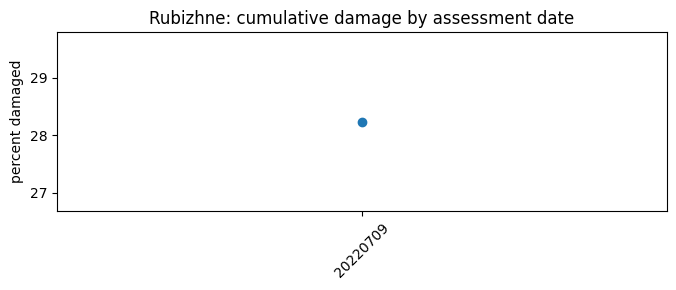


Rubizhne 20220709   PWTT   8,899 buildings, 33.67 percent damaged
                ours  10,984 buildings, 28.24 percent damaged
   matched 8,678 buildings, agreement 99.8 percent
pwtt     0     1
ours            
0     5678     6
1        8  2986


In [40]:
import matplotlib.pyplot as plt


def load_label_csv(path):
    """Read a label CSV back into a GeoDataFrame (the notebook 1 format)."""
    df = pd.read_csv(path, low_memory=False)
    return gpd.GeoDataFrame(
        df.drop(columns=[".geo"]),
        geometry=[geometry.shape(json.loads(g)) for g in df[".geo"]],
        crs="EPSG:4326")


for city, dates in dates_by_city.items():
    shares = []
    for d in dates:
        s = pd.read_csv(os.path.join(OUT_DIR, f"{city}_{d}_1_footprints.csv"),
                        usecols=["class"])["class"]
        shares.append(s.mean() * 100)
        print(f"   {d}: {shares[-1]:5.2f} percent damaged of {len(s):,}")
    if any(b < a - 1e-9 for a, b in zip(shares, shares[1:])):
        print("   WARNING: the damaged share fell between dates. Damage is "
              "cumulative, so this points to a problem in the pooling or join.")

    plt.figure(figsize=(7, 3))
    plt.plot(dates, shares, marker="o")
    plt.ylabel("percent damaged")
    plt.title(f"{city}: cumulative damage by assessment date")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # compare with the published benchmark, where we share a date
    for d in dates:
        bench = os.path.join(PWTT_DIR, f"{city}_{d}_1_footprints.csv")
        if not os.path.exists(bench):
            continue
        pwtt = load_label_csv(bench)
        ours = load_label_csv(os.path.join(OUT_DIR, f"{city}_{d}_1_footprints.csv"))
        print(f"\n{city} {d}   PWTT {len(pwtt):>7,} buildings, "
              f"{pwtt['class'].mean() * 100:5.2f} percent damaged")
        print(f"{'':16s}ours {len(ours):>7,} buildings, "
              f"{ours['class'].mean() * 100:5.2f} percent damaged")

        # match building to building on centroids, then compare labels
        utm = ours.estimate_utm_crs()
        a = ours.to_crs(utm).copy();  a["geometry"] = a.centroid
        b = pwtt.to_crs(utm).copy();  b["geometry"] = b.centroid
        m = gpd.sjoin_nearest(a[["geometry", "class"]], b[["geometry", "class"]],
                              max_distance=5, how="inner",
                              lsuffix="ours", rsuffix="pwtt")
        m = m[~m.index.duplicated()]
        print(f"   matched {len(m):,} buildings, agreement "
              f"{(m['class_ours'] == m['class_pwtt']).mean() * 100:.1f} percent")
        print(pd.crosstab(m["class_ours"], m["class_pwtt"],
                          rownames=["ours"], colnames=["pwtt"]).to_string())

**Reading the crosstab.** A large `ours=0, pwtt=1` cell means our join is
missing points, so raise `SNAP_M`. A large `ours=1, pwtt=0` cell means it is
too generous, so lower it. Roughly balanced off-diagonals mean the two
footprint layers simply disagree about which buildings exist, which no
setting will fix.

## 8. Optional — restore the PWTT baseline

Notebook 2 compares our model against the PWTT statistic, which lives in the
`max_change` column. Two ways to get it:

**Copy it from the benchmark**, for dates the benchmark covers. After the
centroid match in Section 7, `max_change` (and `k50`, `k100`, `k150`) can be
transferred onto our footprints with no Earth Engine call at all.

**Or compute it** for the other dates:

```python
!pip install pwtt
import ee, pwtt
ee.Initialize(project="your-project")

image = pwtt.detect_damage(aoi=..., war_start="2023-10-07",
                           inference_start="2024-05-01",
                           pre_interval=12, post_interval=1)
```

The image has a `T_statistic` band; reducing it over each footprint gives
`max_change`. Check the package's current API first, and note that a
statistic you computed is not the same artifact as the published numbers, so
say which one you used.

One detail from PWTT's `eval.py` worth copying if you want to reproduce their
headline AUC: their metrics are **area-weighted** (`sample_weight=area` in
every scikit-learn call), so large buildings count more than small ones.
Unweighted metrics on the same data give different numbers.

Without `max_change`, notebook 2 still trains and evaluates normally; it just
omits the PWTT comparison rows.

## Next steps

1. In `pipeline.py`, point the label folder at this notebook's output:

   ```python
   DATA_DIR = os.path.join(BASE, "own_footprints")
   ```

2. Copy the `CITY_REGISTRY` lines printed in Section 6 into `pipeline.py`,
   keeping the dates **oldest first**.
3. Run **notebook 1** to export imagery and cut patches for every date.
4. In **notebook 2**, set `label_temporal: True`.

Two cautions. If any two of your dates are less than a month apart, set
`post_direction: "backward"` in `PREP`, or a forward imagery window reaches
past the next assessment and shows the model damage its label denies. And
more dates means more Sentinel exports and more patches on Drive — start with
one city and check the sizes before adding more.